In [2]:
import pandas as pd

# Read the CSV file
file_path = r"C:\Users\egor1\Desktop\Energy\SCUC\SCUCa\results\merged_results.csv"
data = pd.read_csv(file_path)

data = data.drop_duplicates()
# Display the first few rows of the data
data.head()

,timestamp,instance_name,case_folder,mode,tau,status,status_code,runtime_sec,wall_sec,mip_gap,...,logfile,mode_clean,with_LAZY,with_PRUNE,with_GNN,with_COMMIT,with_GRU,with_BANDIT,obj_raw,obj_ppm_vs_raw
0,2025-09-15 14:09:21,matpower/case118/2017-01-09,matpower/case118,RAW,NaN,OPTIMAL,2,40.843,76.046208,0.000102,...,exp_matpower_case118_20250915_170805.csv,RAW,False,False,False,False,False,False,7.078283e+06,0.0
3,2025-09-15 14:10:36,matpower/case118/2017-01-09,matpower/case118,RAW+GNN,NaN,OPTIMAL,2,40.814,75.573695,0.000102,...,exp_matpower_case118_20250915_170805.csv,RAW+GNN,False,False,True,False,False,False,7.078283e+06,0.0
6,2025-09-15 14:11:52,matpower/case118/2017-01-09,matpower/case118,RAW+COMMIT,NaN,OPTIMAL,2,40.761,75.718318,0.000102,...,exp_matpower_case118_20250915_170805.csv,RAW+COMMIT,False,False,False,True,False,False,7.078283e+06,0.0
9,2025-09-15 14:13:10,matpower/case118/2017-01-09,matpower/case118,WARM,NaN,OPTIMAL,2,40.754,77.740913,0.000102,...,exp_matpower_case118_20250915_170805.csv,WARM,False,False,False,False,False,False,7.078283e+06,0.0
12,2025-09-15 14:14:27,matpower/case118/2017-01-09,matpower/case118,WARM+HINTS,NaN,OPTIMAL,2,40.776,77.424791,0.000102,...,exp_matpower_case118_20250915_170805.csv,WARM+HINTS,False,False,False,False,False,False,7.078283e+06,0.0


In [3]:
# Drop rows whose mode uses K128 (e.g., 'WARM+LAZY+K128')
if "data" not in globals():
    raise RuntimeError("Variable 'data' not found.")

_k128_mask = data["mode_clean"].astype(str).str.contains("PRUNE-0.70", na=False)
removed_k128_rows = int(_k128_mask.sum())

if removed_k128_rows == 0:
    print("No K128 modes found; nothing removed.")
else:
    data = data.loc[~_k128_mask].copy()
    print(f"Removed {removed_k128_rows} rows with K128 modes.")
    # Refresh basic cached aggregates if they existed
    if "total_rows" in globals():
        total_rows = len(data)
    if "unique_modes" in globals():
        unique_modes = data["mode_clean"].nunique()
    if "total_runtime_sec" in globals():
        total_runtime_sec = data["runtime_sec"].sum()
        total_runtime_hours = total_runtime_sec / 3600

    # Invalidate derived speedup / pivot artifacts so downstream cells recompute with filtered data
    for _var in [
        "pvt",
        "speedup_inst_df",
        "avg_speedup",
        "avg_speedup_all",
        "opt_share_by_mode",
        "sumdf",
        "win_share_mode",
        "win_share_family",
    ]:
        if _var in globals():
            del globals()[_var]

Removed 20 rows with K128 modes.


In [4]:
# Group by case_folder and show counts per group
case_folder_groups = data.groupby("case_folder")

case_folder_counts = (
    case_folder_groups.size()
    .reset_index(name="n_rows")
    .sort_values("n_rows", ascending=False)
)

case_folder_counts

,case_folder,n_rows
3,matpower/case300,1495
4,matpower/case57,1380
5,matpower/case89pegase,1242
2,matpower/case30,1219
1,matpower/case14,1196
0,matpower/case118,1150


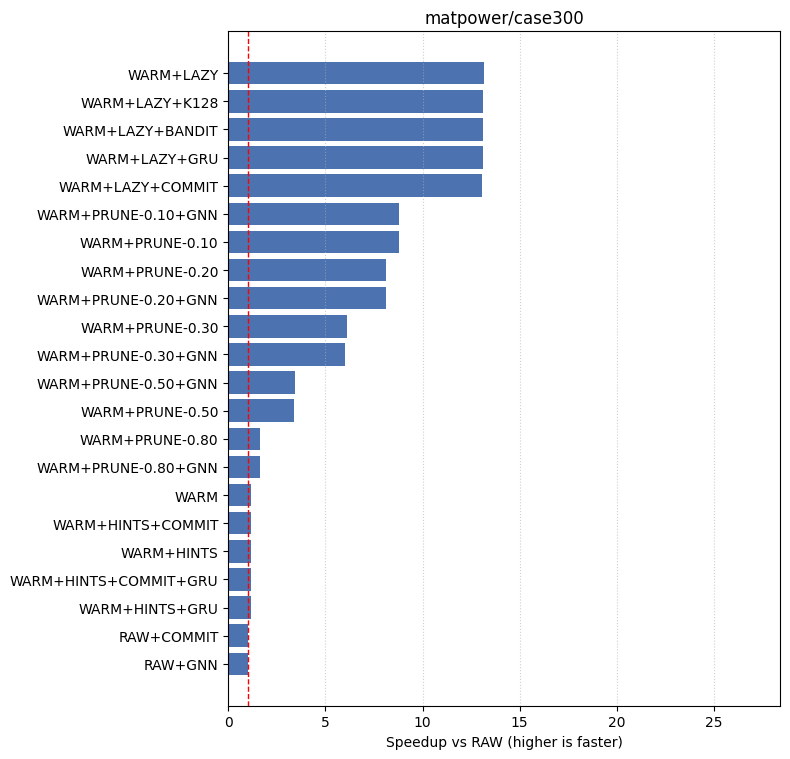

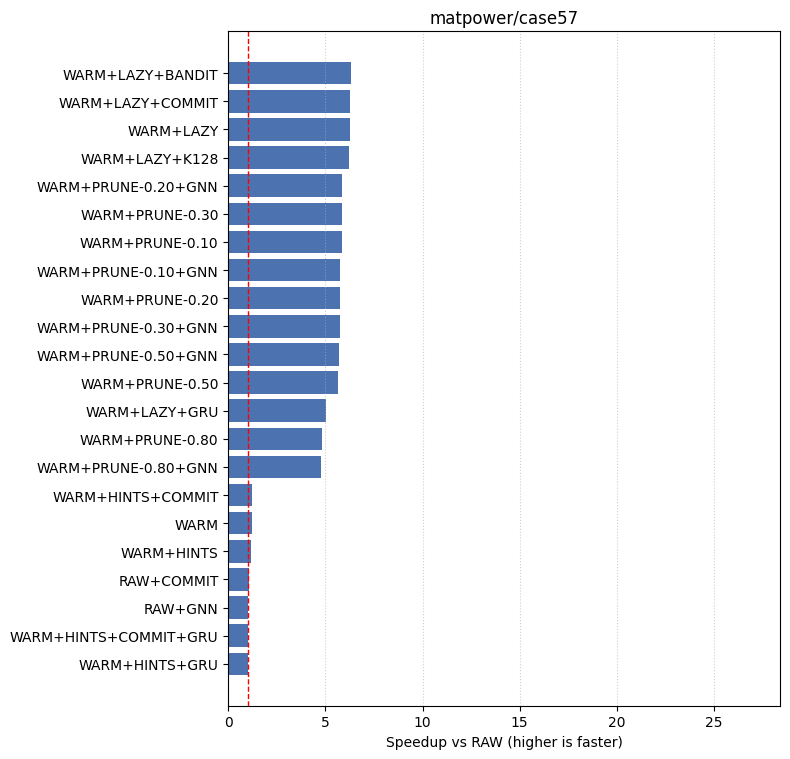

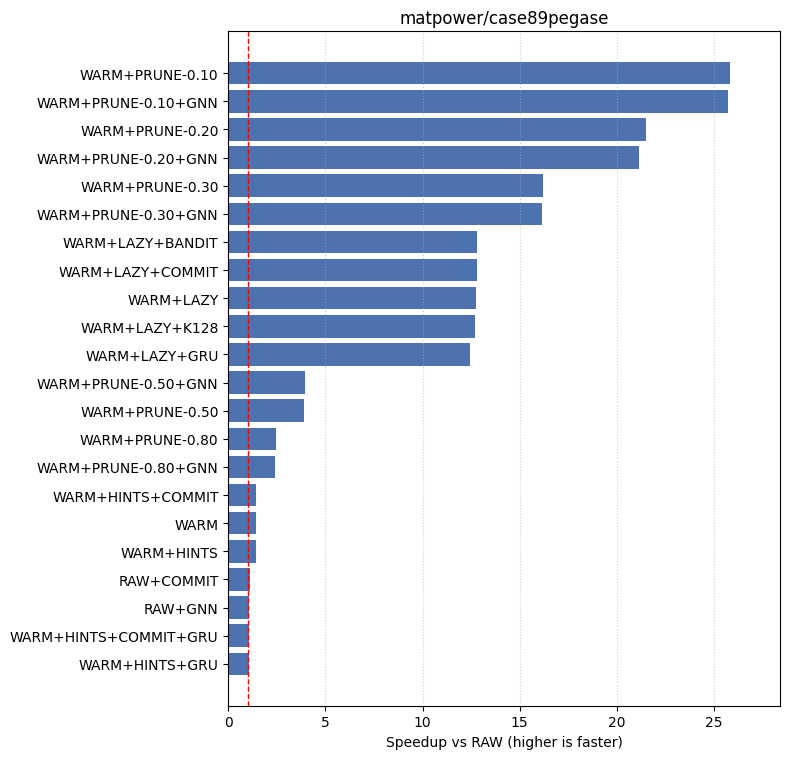

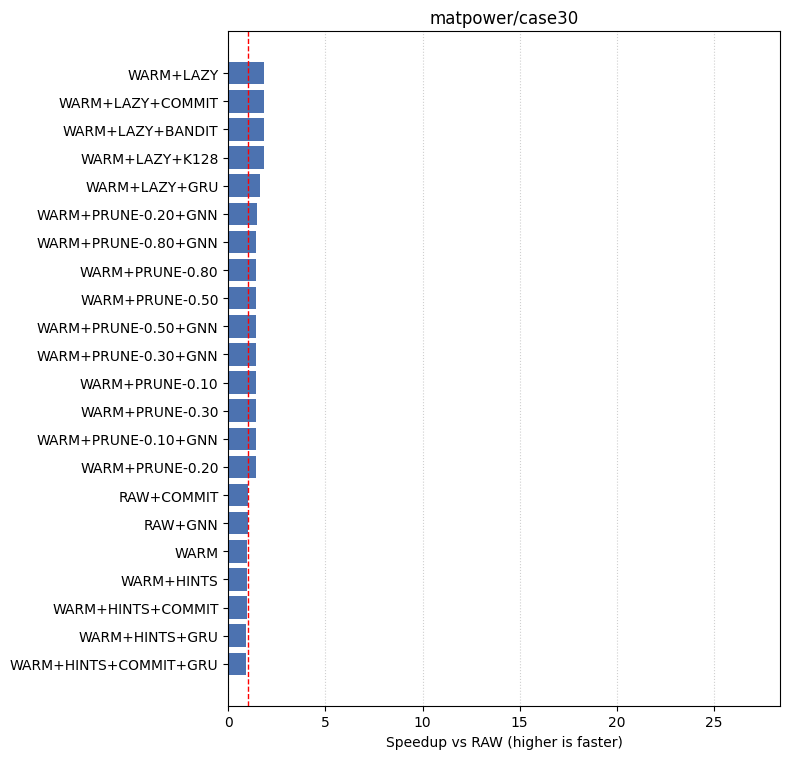

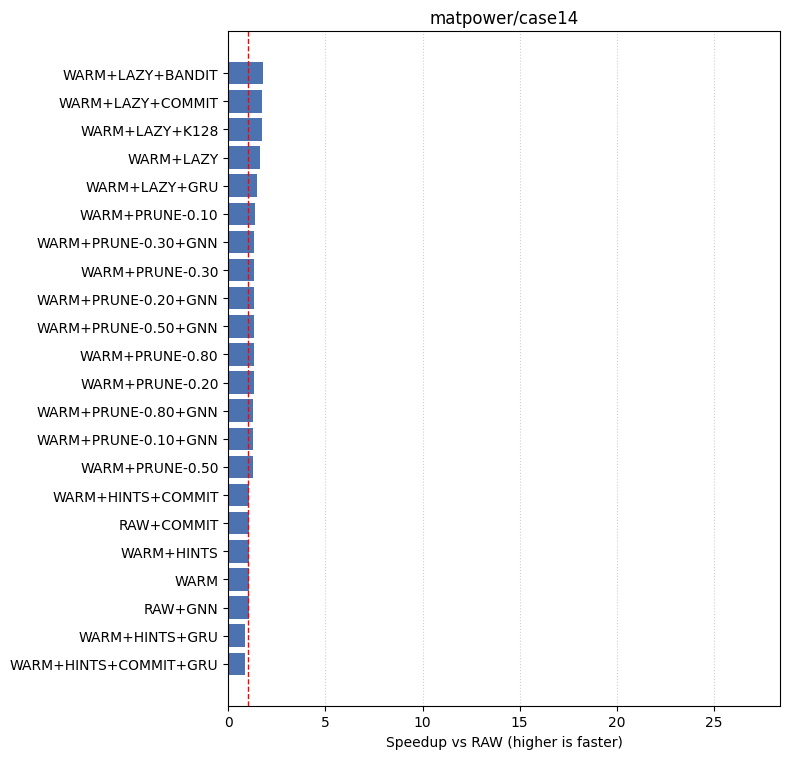

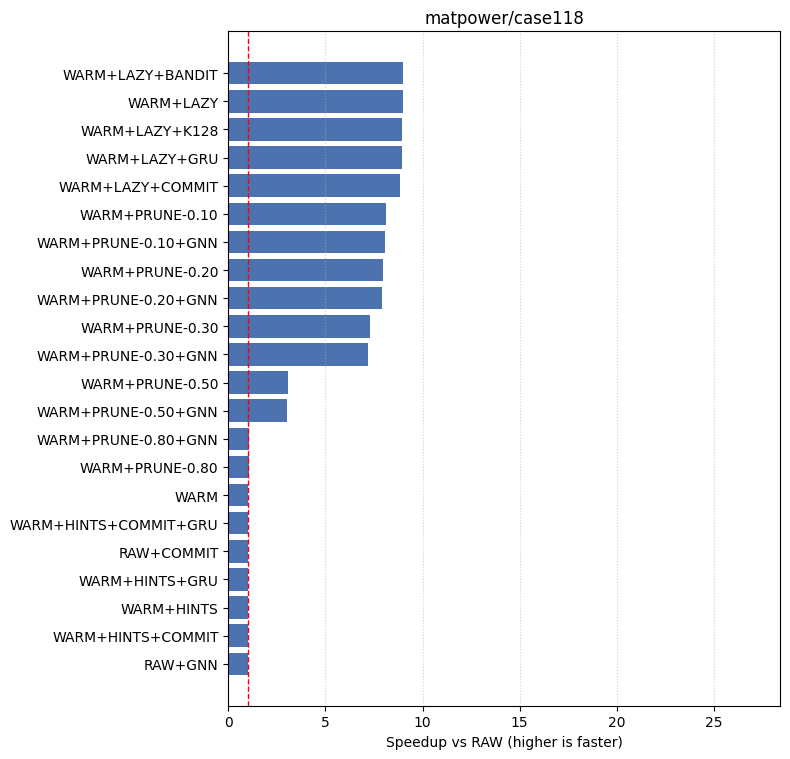

In [5]:
import matplotlib.pyplot as plt

# Use only successful runs
df_ok = data.loc[
    data["status"] == "OPTIMAL",
    ["case_folder", "instance_name", "mode_clean", "runtime_sec"],
]

# Pivot to align runtimes of different modes for the same (case_folder, instance_name)
pvt = df_ok.pivot_table(
    index=["case_folder", "instance_name"],
    columns="mode_clean",
    values="runtime_sec",
    aggfunc="mean",
)

if "RAW" not in pvt.columns:
    print("No RAW baseline found; cannot compute speedup.")
else:
    # Per-instance speedup vs RAW for each mode (RAW/Mode)
    modes = [m for m in pvt.columns if m != "RAW"]
    speedup_inst_df = pd.DataFrame(
        {m: pvt["RAW"] / pvt[m] for m in modes}, index=pvt.index
    )

    # Average speedup across instances for each case_folder
    avg_speedup = speedup_inst_df.groupby(level="case_folder").mean()
    avg_speedup = avg_speedup.dropna(how="all")

    if avg_speedup.empty:
        print("No comparable instances with RAW baseline found.")
    else:
        # Order cases using existing case_folder_counts if available
        if "case_folder_counts" in globals():
            ordered_cases = [
                c
                for c in case_folder_counts["case_folder"].tolist()
                if c in avg_speedup.index
            ]
            ordered_cases += [c for c in avg_speedup.index if c not in ordered_cases]
        else:
            ordered_cases = list(avg_speedup.index)

        # Global x-limit shared across figures
        y_max = float(avg_speedup.max().max())
        y_max = 1.1 * y_max if y_max > 0 else 1.5

        # One figure per case_folder, modes listed vertically
        for case in ordered_cases:
            s = avg_speedup.loc[case].dropna()
            order = s.sort_values(ascending=False).index.tolist()

            # Dynamic height to fit all modes
            fig_height = max(3.0, 0.35 * max(1, len(order)))
            fig, ax = plt.subplots(figsize=(8, fig_height))

            if len(order) == 0:
                # ax.set_title(case)
                ax.axvline(1.0, color="red", linestyle="--", linewidth=1)
                ax.set_xlim(0, y_max)
                ax.set_yticks([])
            else:
                ax.barh(order, s.loc[order], color="#4C72B0")
                ax.axvline(
                    1.0, color="red", linestyle="--", linewidth=1
                )  # RAW baseline
                ax.set_title(case)
                ax.set_xlim(0, y_max)
                ax.set_xlabel("Speedup vs RAW (higher is faster)")
                ax.grid(axis="x", linestyle=":", alpha=0.6)
                ax.invert_yaxis()  # highest speedup on top

            plt.tight_layout()
            plt.show()


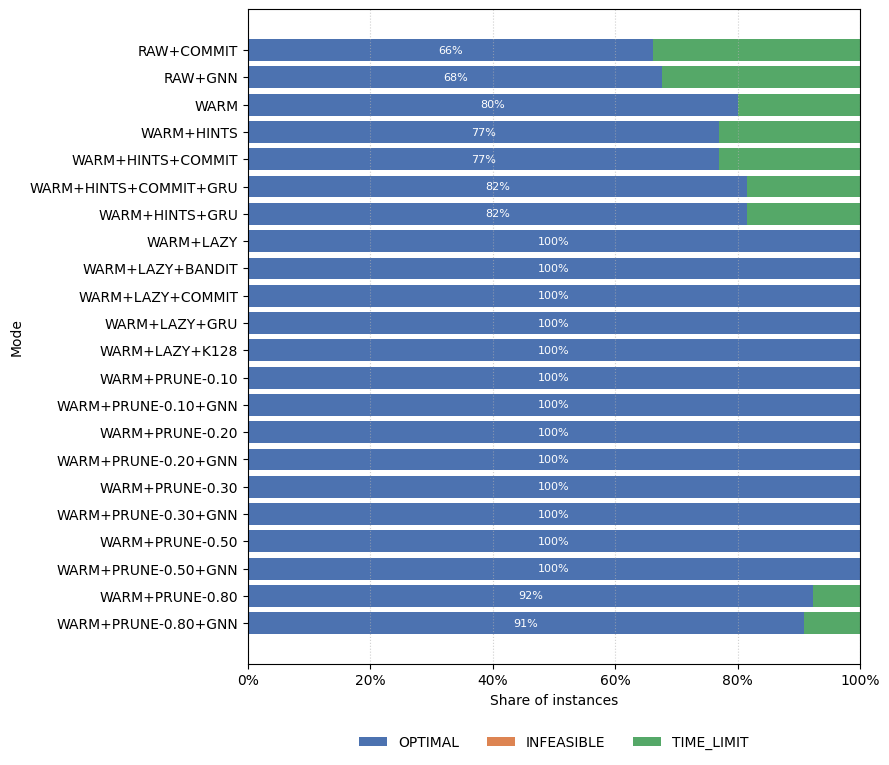

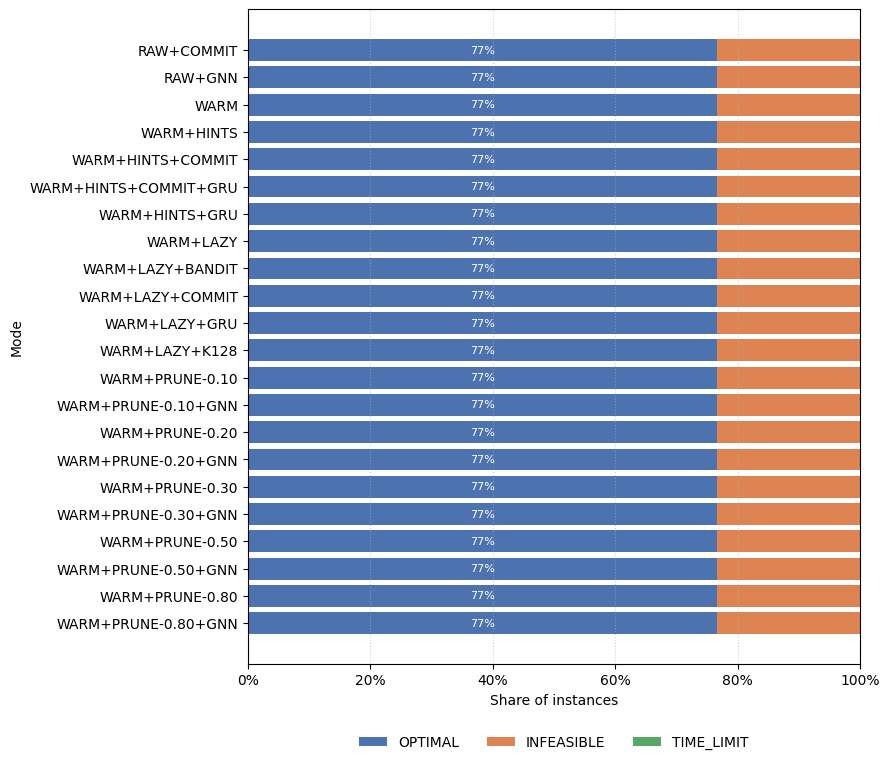

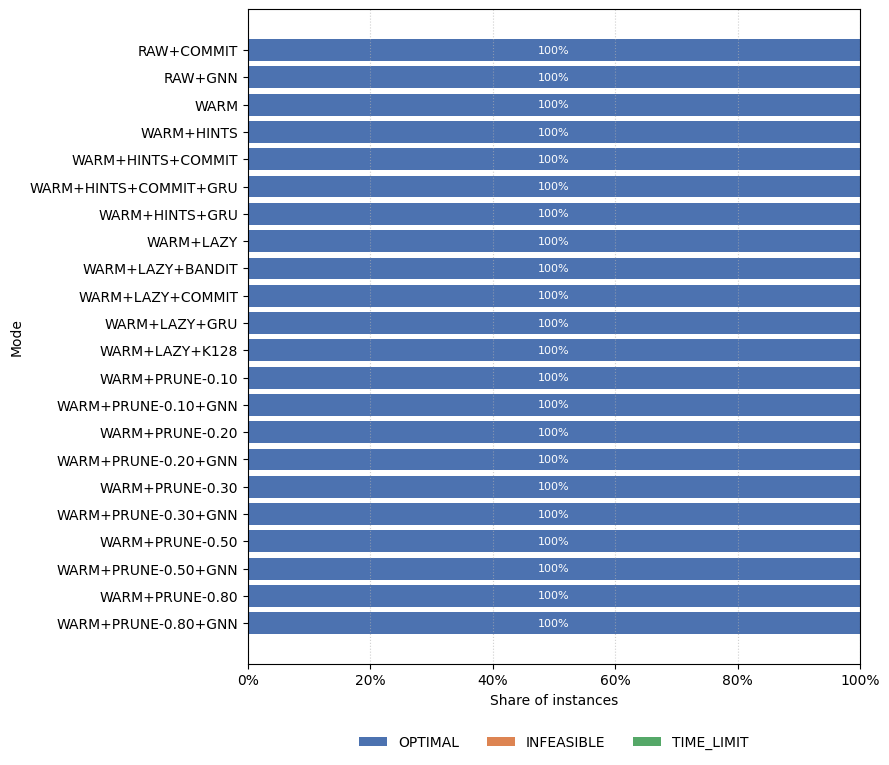

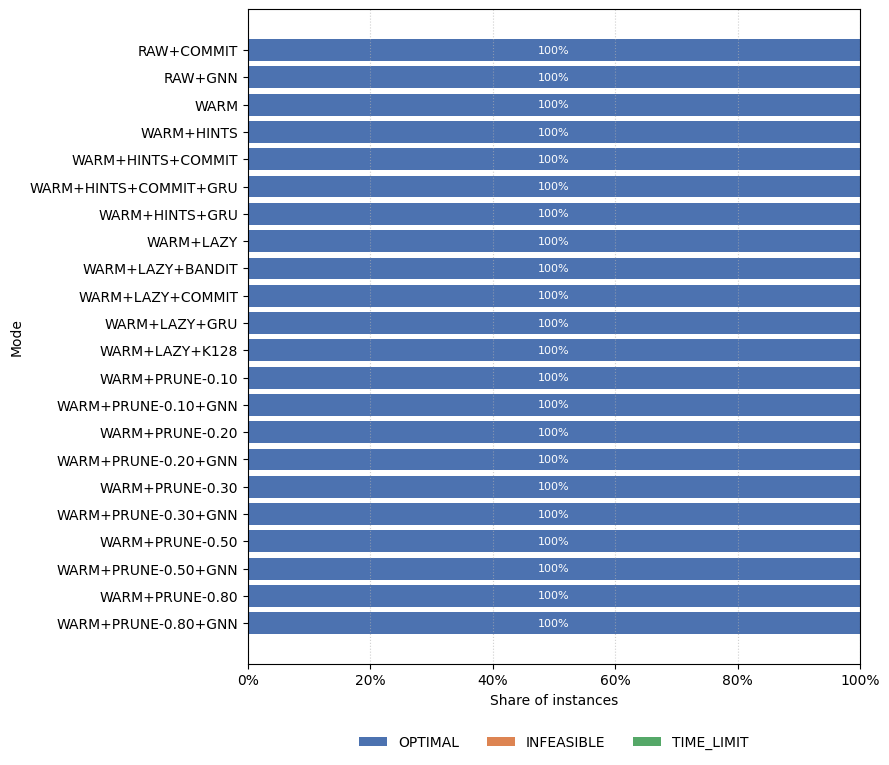

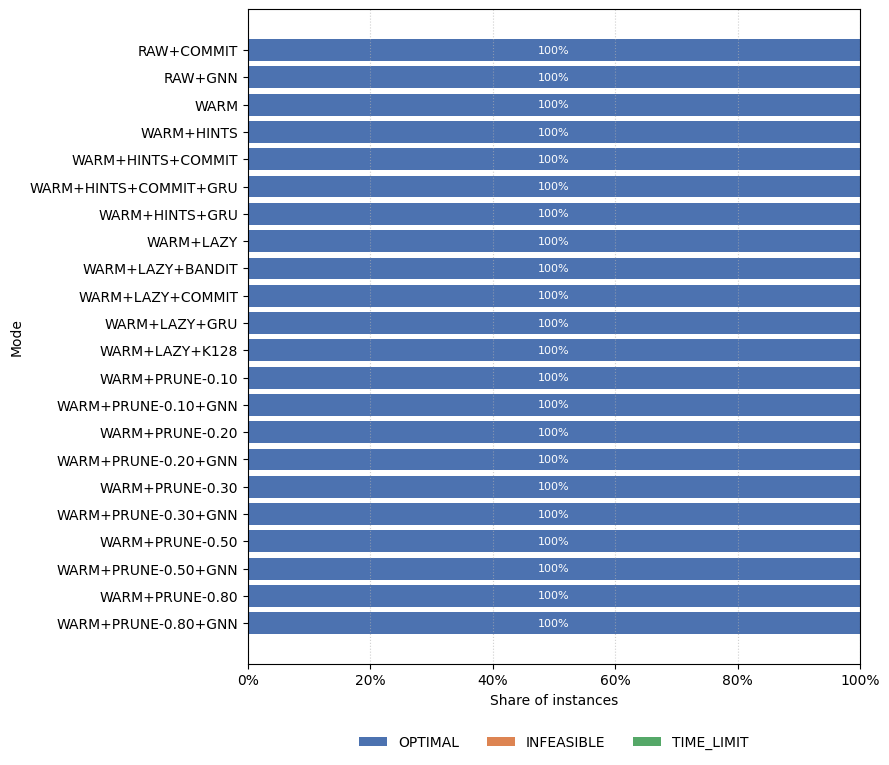

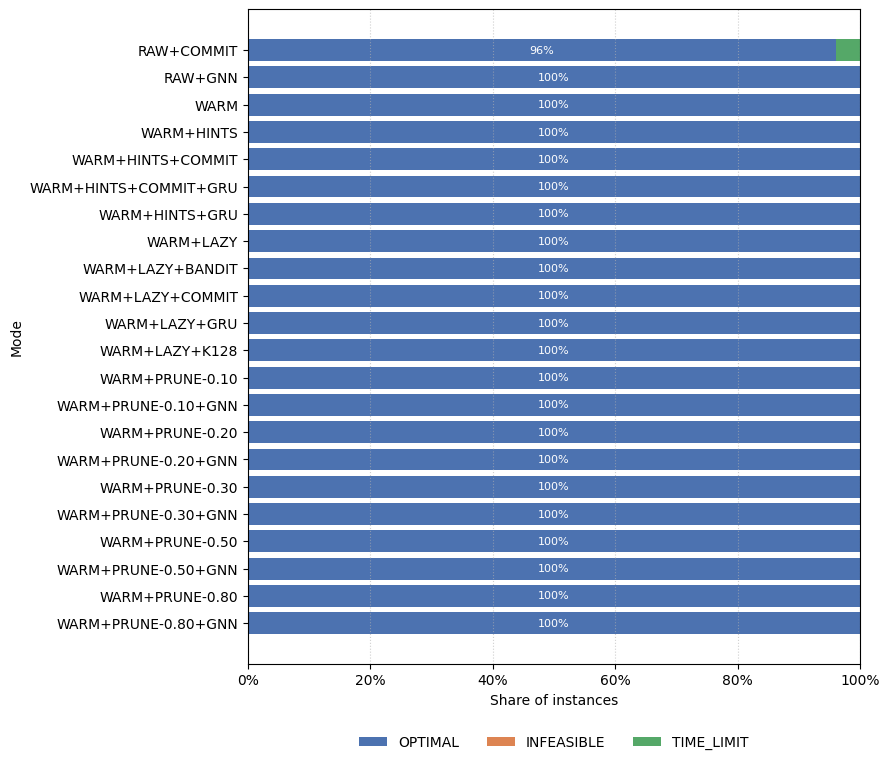

In [6]:
from matplotlib.ticker import PercentFormatter

# Per-case, all-modes 100% stacked status plots

status_categories = ["OPTIMAL", "INFEASIBLE", "TIME_LIMIT"]
status_counts_mode = (
    data[data["status"].isin(status_categories)]
    .groupby(["case_folder", "mode_clean", "status"])
    .size()
    .unstack(fill_value=0)
)

# Order cases using existing case_folder_counts if available
if "case_folder_counts" in globals():
    ordered_cases = [
        c
        for c in case_folder_counts["case_folder"].tolist()
        if c in status_counts_mode.index.get_level_values("case_folder")
    ]
    ordered_cases += [
        c
        for c in status_counts_mode.index.get_level_values("case_folder").unique()
        if c not in ordered_cases
    ]
else:
    ordered_cases = list(
        status_counts_mode.index.get_level_values("case_folder").unique()
    )


def modes_for_case(case):
    available = status_counts_mode.loc[case].index.tolist()
    if "modes" in globals():
        return [m for m in modes if m in available]
    return available


colors = {
    "OPTIMAL": "#4C72B0",  # blue
    "INFEASIBLE": "#DD8452",  # orange
    "TIME_LIMIT": "#55A868",  # green
}

for case in ordered_cases:
    # counts per mode (rows) x status (cols)
    counts = status_counts_mode.loc[case].reindex(columns=status_categories).fillna(0)
    if counts.empty:
        continue

    # proportions per mode (each row sums to 1)
    props = counts.div(counts.sum(axis=1), axis=0).fillna(0)

    order_modes = modes_for_case(case)
    props = props.loc[order_modes]

    fig_height = max(3.0, 0.35 * max(1, len(props)))
    fig, ax = plt.subplots(figsize=(9, fig_height))

    left = None
    for i, status in enumerate(status_categories):
        vals = props[status].values
        if i == 0:
            left = [0.0] * len(vals)
        ax.barh(props.index, vals, left=left, color=colors[status], label=status)
        left = [l + v for l, v in zip(left, vals)]

    # annotate OPTIMAL percentage inside bars
    if "OPTIMAL" in props.columns:
        opt_vals = props["OPTIMAL"].values
        for y, v in zip(range(len(props.index)), opt_vals):
            if v > 0.03:
                ax.text(
                    v / 2,
                    y,
                    f"{v * 100:.0f}%",
                    va="center",
                    ha="center",
                    color="white",
                    fontsize=8,
                )

    # ax.set_title(f"{case}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of instances")
    ax.set_ylabel("Mode")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    ax.invert_yaxis()
    ax.legend(
        loc="upper center",
        ncol=len(status_categories),
        bbox_to_anchor=(0.5, -0.09),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()

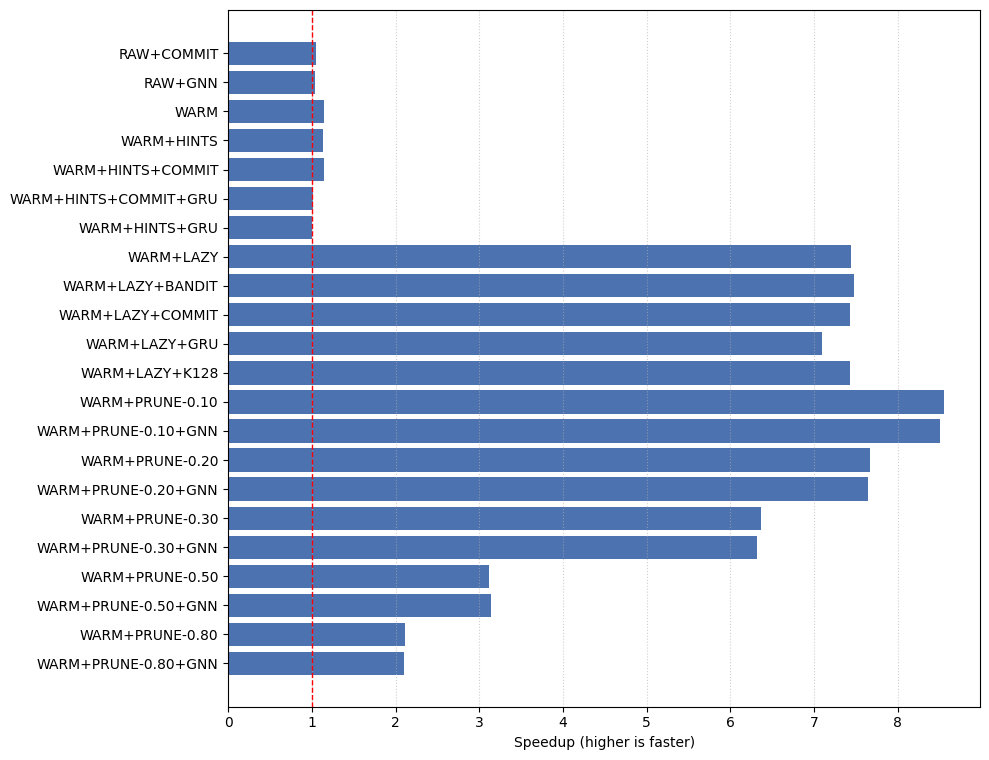

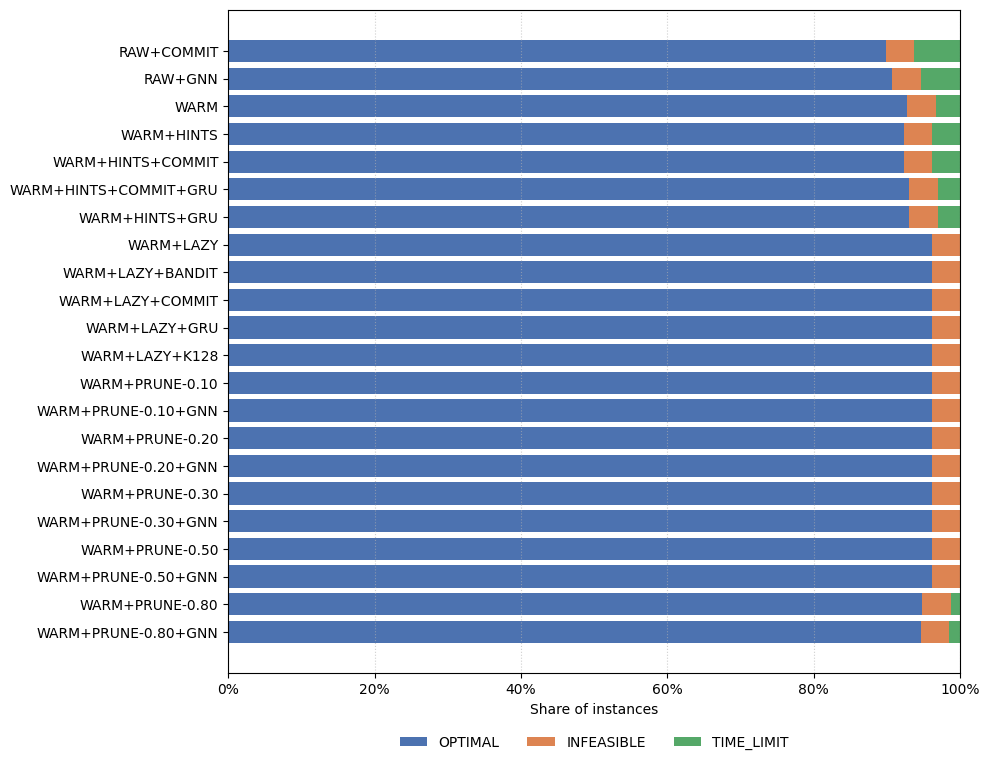

In [7]:
# Average across all cases: speedup vs RAW and optimality percentage per mode

# Explicit desired ordering
_target_modes_order = [
    "RAW+COMMIT",
    "RAW+GNN",
    "WARM",
    "WARM+HINTS",
    "WARM+HINTS+COMMIT",
    "WARM+HINTS+COMMIT+GRU",
    "WARM+HINTS+GRU",
    "WARM+LAZY",
    "WARM+LAZY+BANDIT",
    "WARM+LAZY+COMMIT",
    "WARM+LAZY+GRU",
    "WARM+LAZY+K128",
    "WARM+PRUNE-0.10",
    "WARM+PRUNE-0.10+GNN",
    "WARM+PRUNE-0.20",
    "WARM+PRUNE-0.20+GNN",
    "WARM+PRUNE-0.30",
    "WARM+PRUNE-0.30+GNN",
    "WARM+PRUNE-0.50",
    "WARM+PRUNE-0.50+GNN",
    "WARM+PRUNE-0.80",
    "WARM+PRUNE-0.80+GNN",
]
# Keep only those present
modes_order = [m for m in _target_modes_order if m in avg_speedup.columns]

# 1) Average speedup across cases (equal weight per case)
avg_speedup_all = avg_speedup.mean(axis=0).reindex(modes_order).dropna()

fig_h = max(3.0, 0.35 * max(1, len(avg_speedup_all)))
fig, ax = plt.subplots(figsize=(10, fig_h))
ax.barh(avg_speedup_all.index, avg_speedup_all.values, color="#4C72B0")
ax.axvline(1.0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Speedup (higher is faster)")
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 2) Average optimality percentage across cases
opt_share_per_case_mode = status_counts_mode["OPTIMAL"] / status_counts_mode.sum(axis=1)
opt_share_by_mode = opt_share_per_case_mode.groupby(level="mode_clean").mean()
opt_share_by_mode = opt_share_by_mode.reindex(modes_order).dropna()

shares_per_case = (
    status_counts_mode[status_categories]
    .div(status_counts_mode.sum(axis=1), axis=0)
    .fillna(0)
)
avg_shares_by_mode = shares_per_case.groupby(level="mode_clean").mean()
avg_shares_by_mode = avg_shares_by_mode.reindex(modes_order).dropna(how="all")

fig_h = max(3.0, 0.35 * max(1, len(avg_shares_by_mode)))
fig, ax = plt.subplots(figsize=(10, fig_h))

left = [0.0] * len(avg_shares_by_mode)
for st in status_categories:
    vals = avg_shares_by_mode[st].values
    ax.barh(
        avg_shares_by_mode.index,
        vals,
        left=left,
        color=colors.get(st, None),
        label=st,
    )
    left = [l + v for l, v in zip(left, vals)]

ax.set_xlabel("Share of instances")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.invert_yaxis()
ax.legend(
    loc="upper center",
    ncol=len(status_categories),
    bbox_to_anchor=(0.5, -0.075),
    frameon=False,
)
plt.tight_layout()
plt.show()

C:\Users\egor1\AppData\Local\Temp\ipykernel_17092\3369062952.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


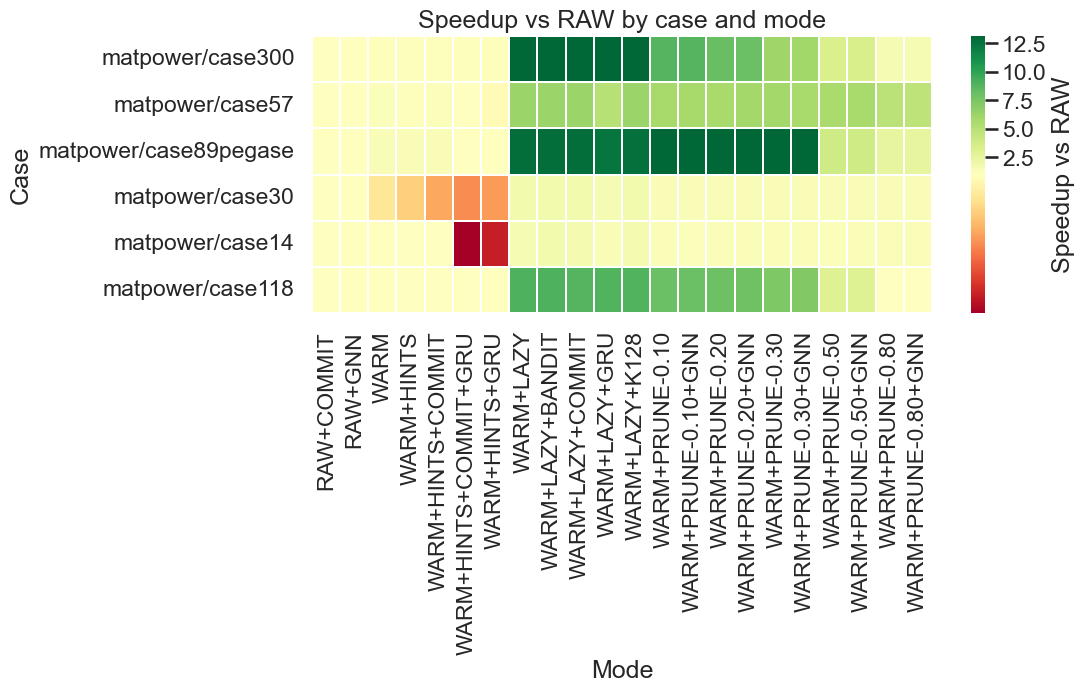

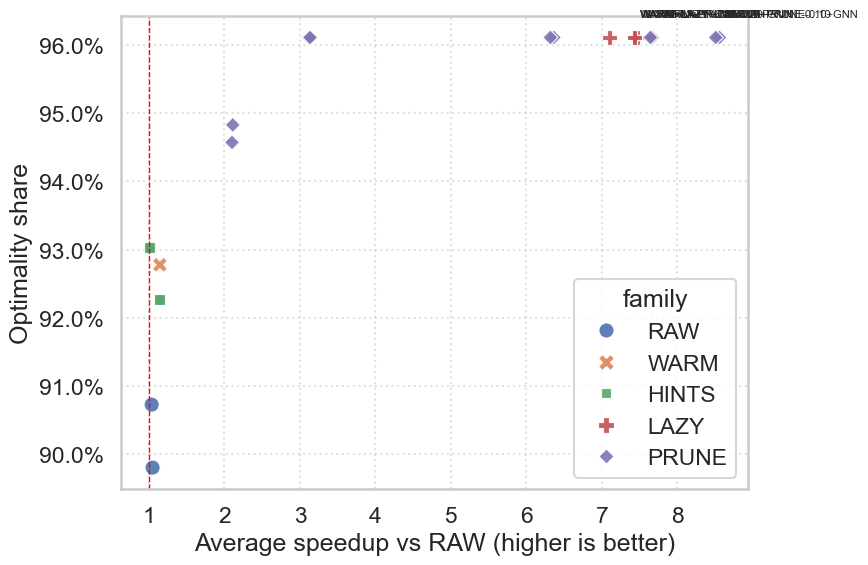

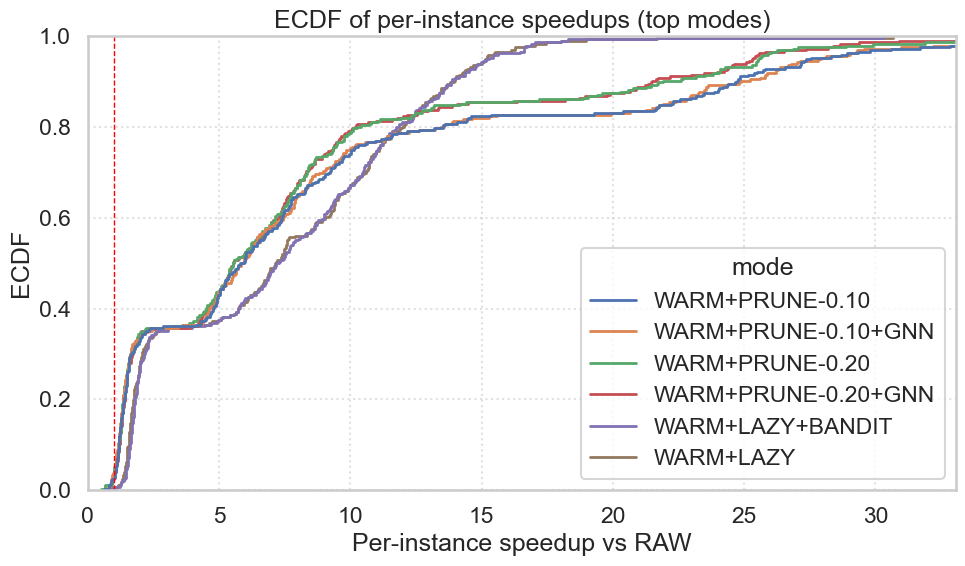

C:\Users\egor1\AppData\Local\Temp\ipykernel_17092\3369062952.py:126: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  winners_mode = speedup_inst_df.idxmax(axis=1)


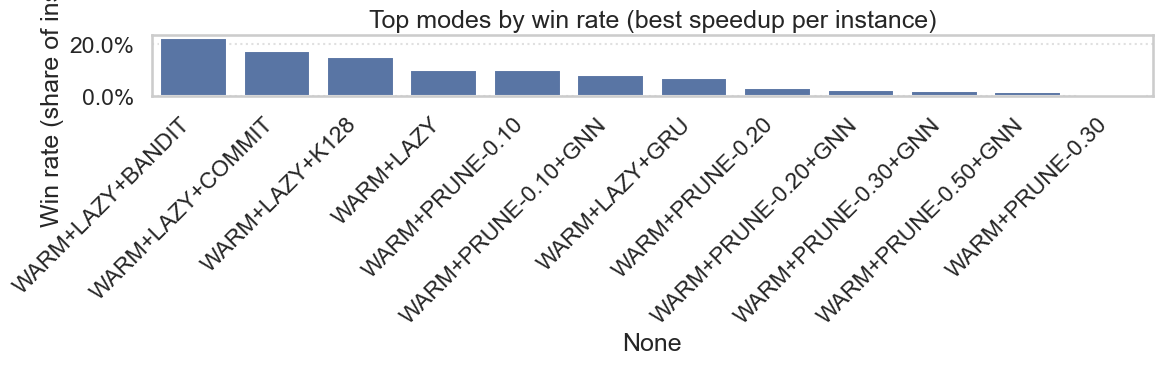

C:\Users\egor1\AppData\Local\Temp\ipykernel_17092\3369062952.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=win_share_family.index, y=win_share_family.values, palette="Set2")


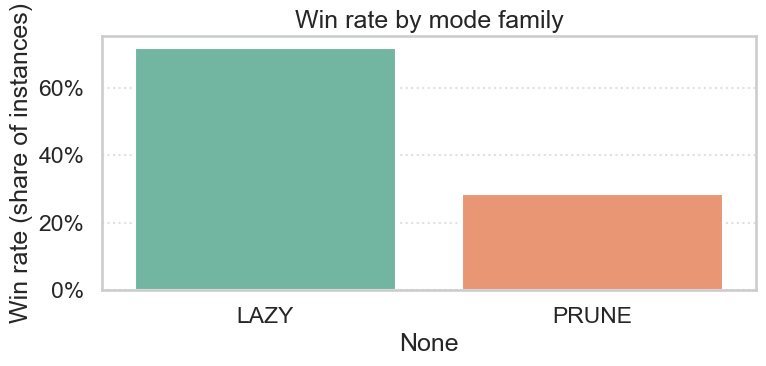

C:\Users\egor1\AppData\Local\Temp\ipykernel_17092\3369062952.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


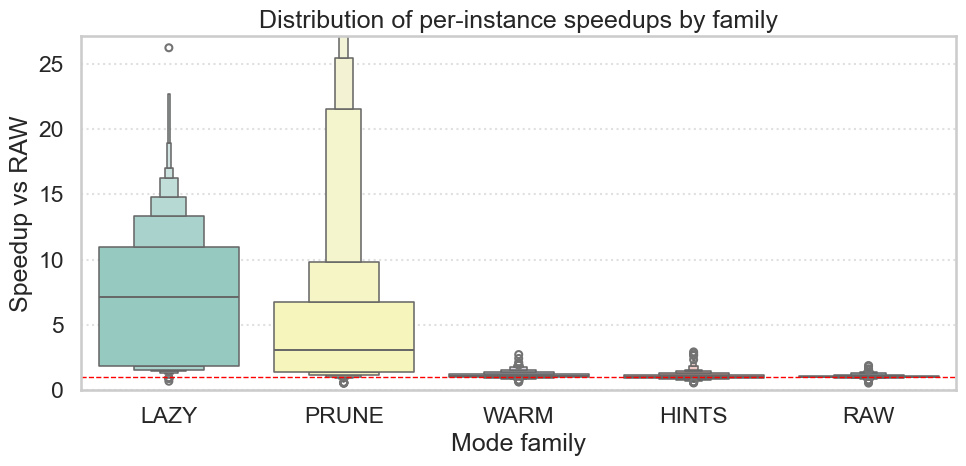

In [8]:
import seaborn as sns
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import PercentFormatter
import pandas as pd
import matplotlib.pyplot as plt

# Compatibility shim: allow DataFrame.dropna(..., errors="ignore") on older pandas
if not getattr(pd.DataFrame, "_dropna_shim_applied", False):
    _pd_dropna_orig = pd.DataFrame.dropna

    def _dropna_shim(self, *args, **kwargs):
        kwargs.pop("errors", None)
        return _pd_dropna_orig(self, *args, **kwargs)

    pd.DataFrame.dropna = _dropna_shim
    pd.DataFrame._dropna_shim_applied = True
# Additional analysis plots using seaborn

sns.set_theme(style="whitegrid", context="talk")


# Helpers
def mode_family(m: str) -> str:
    if "LAZY" in m:
        return "LAZY"
    if "PRUNE" in m:
        return "PRUNE"
    if "HINTS" in m:
        return "HINTS"
    if m.startswith("RAW"):
        return "RAW"
    if m.startswith("WARM"):
        return "WARM"
    return "OTHER"


# 1) Heatmap: per-case average speedup vs RAW (higher is better)
cases = ordered_cases if "ordered_cases" in globals() else list(avg_speedup.index)
cols = modes if "modes" in globals() else list(avg_speedup.columns)
hdata = avg_speedup.reindex(index=cases, columns=cols)

fig_w = max(10, 0.45 * max(8, len(cols)))
fig_h = max(3.5, 0.6 * max(1, len(cases)))
norm = TwoSlopeNorm(
    vmin=np.nanmin(hdata.values), vcenter=1.0, vmax=np.nanpercentile(hdata.values, 95)
)

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    hdata,
    cmap="RdYlGn",
    norm=norm,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Speedup vs RAW"},
    annot=False,
)
plt.title("Speedup vs RAW by case and mode")
plt.xlabel("Mode")
plt.ylabel("Case")
plt.tight_layout()
plt.show()

# 2) Scatter: average speedup vs average optimality share per mode (Pareto view)
sumdf = pd.DataFrame(
    {
        "mode": avg_speedup_all.index,
        "avg_speedup": avg_speedup_all.values,
        "opt_share": opt_share_by_mode.reindex(avg_speedup_all.index).values,
    }
)
sumdf["family"] = sumdf["mode"].apply(mode_family)

plt.figure(figsize=(9, 6))
ax = sns.scatterplot(
    data=sumdf,
    x="avg_speedup",
    y="opt_share",
    hue="family",
    style="family",
    s=120,
    alpha=0.9,
)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Average speedup vs RAW (higher is better)")
ax.set_ylabel("Optimality share")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="both", linestyle=":", alpha=0.6)

# label top-k by speedup
for _, r in sumdf.nlargest(8, "avg_speedup").iterrows():
    ax.text(
        r["avg_speedup"] * 1.01,
        min(0.999, r["opt_share"] + 0.003),
        r["mode"],
        fontsize=8,
    )

plt.tight_layout()
plt.show()

# 3) ECDF: distribution of per-instance speedups for top modes
top_modes = avg_speedup_all.sort_values(ascending=False).head(6).index.tolist()
ecdf_long = (
    speedup_inst_df[top_modes]
    .stack()
    .rename("speedup")
    .reset_index()
    .rename(columns={"level_2": "mode"})
    .dropna(subset=["speedup"])
)

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=ecdf_long, x="speedup", hue="mode", linewidth=2)
plt.axvline(1.0, color="red", linestyle="--", linewidth=1)
plt.xlim(0, np.nanpercentile(ecdf_long["speedup"], 99))
plt.xlabel("Per-instance speedup vs RAW")
plt.ylabel("ECDF")
plt.title("ECDF of per-instance speedups (top modes)")
plt.grid(axis="both", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 4) Win-rate: which mode is best per instance?
winners_mode = speedup_inst_df.idxmax(axis=1)
win_share_mode = winners_mode.value_counts(normalize=True).sort_values(ascending=False)

plt.figure(figsize=(12, 4))
ax = sns.barplot(
    x=win_share_mode.index[:12], y=win_share_mode.values[:12], color="#4C72B0"
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Win rate (share of instances)")
plt.title("Top modes by win rate (best speedup per instance)")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 5) Win-rate by family (LAZY/PRUNE/HINTS/WARM/RAW)
mode_to_family = {m: mode_family(m) for m in speedup_inst_df.columns}
winners_family = winners_mode.map(mode_to_family)
win_share_family = winners_family.value_counts(normalize=True)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=win_share_family.index, y=win_share_family.values, palette="Set2")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.ylabel("Win rate (share of instances)")
plt.title("Win rate by mode family")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 6) Distribution of speedups by family (boxenplot)
speedup_long_all = (
    speedup_inst_df.stack()
    .rename("speedup")
    .reset_index()
    .rename(columns={"level_2": "mode"})
    .dropna(subset=["speedup"])
)
speedup_long_all["family"] = speedup_long_all["mode"].map(mode_to_family)
family_order = (
    speedup_long_all.groupby("family")["speedup"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(10, 5))
sns.boxenplot(
    data=speedup_long_all, x="family", y="speedup", order=family_order, palette="Set3"
)
plt.axhline(1.0, color="red", linestyle="--", linewidth=1)
plt.ylim(0, np.nanpercentile(speedup_long_all["speedup"], 99))
plt.xlabel("Mode family")
plt.ylabel("Speedup vs RAW")
plt.title("Distribution of per-instance speedups by family")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


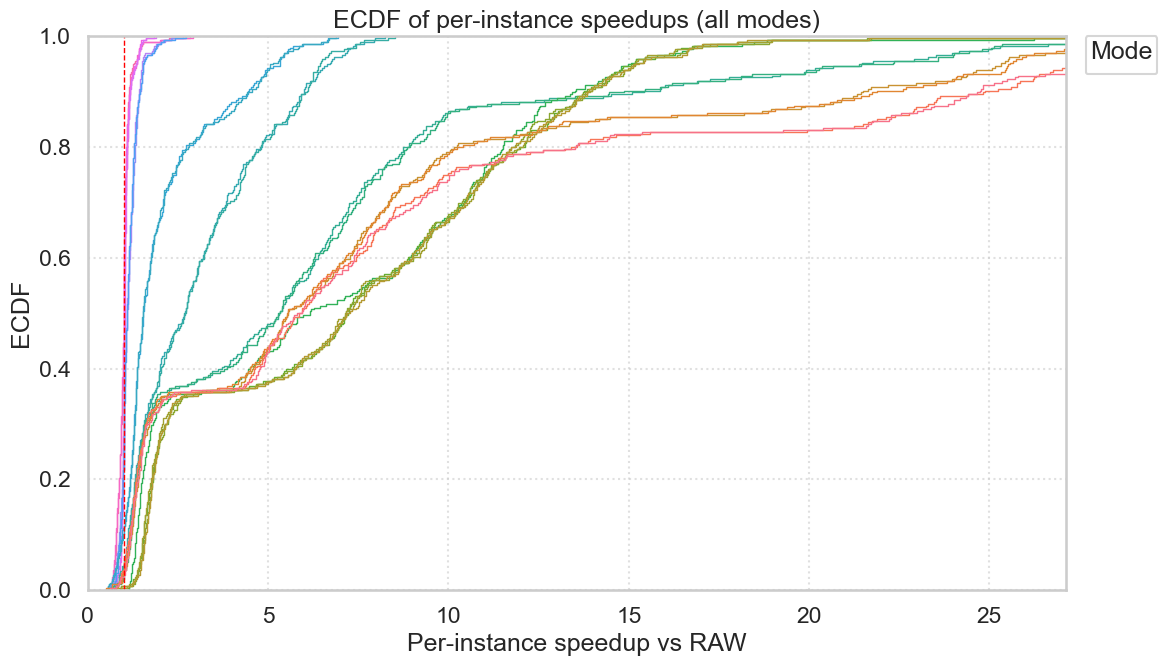

In [9]:
# ECDF (Empirical CDF) of per‑instance speedups (RAW / mode runtime)

if "speedup_inst_df" not in globals():
    raise RuntimeError("speedup_inst_df not available.")

_ecdf_all_long = (
    speedup_inst_df.stack()
    .reset_index()
    .rename(columns={"level_2": "mode", 0: "speedup"})
    .dropna(subset=["speedup"])
)

# Order modes (fastest first if available)
if "avg_speedup_all" in globals():
    _mode_order = avg_speedup_all.sort_values(ascending=False).index.tolist()
else:
    _mode_order = sorted(speedup_inst_df.columns)

plt.figure(figsize=(12, 7))
ax = sns.ecdfplot(
    data=_ecdf_all_long,
    x="speedup",
    hue="mode",
    hue_order=_mode_order,
    linewidth=1,
)

# Baseline speedup = 1
ax.axvline(1.0, color="red", linestyle="--", linewidth=1)

# X range (robust against outliers)
plt.xlim(0, np.nanpercentile(_ecdf_all_long["speedup"], 99))
plt.xlabel("Per-instance speedup vs RAW")
plt.ylabel("ECDF")
plt.title("ECDF of per-instance speedups (all modes)")
plt.grid(axis="both", linestyle=":", alpha=0.6)

# Legend (keep; remove inline colored mode names)
if "avg_speedup_all" in globals():
    _legend_labels = [
        f"{m} (avg {avg_speedup_all[m]:.2f}x)" if m in avg_speedup_all else m
        for m in _mode_order
    ]
else:
    _legend_labels = _mode_order

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles,
    _legend_labels,
    title="Mode",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncol=1,
    fontsize=8,
)

plt.tight_layout()
plt.show()


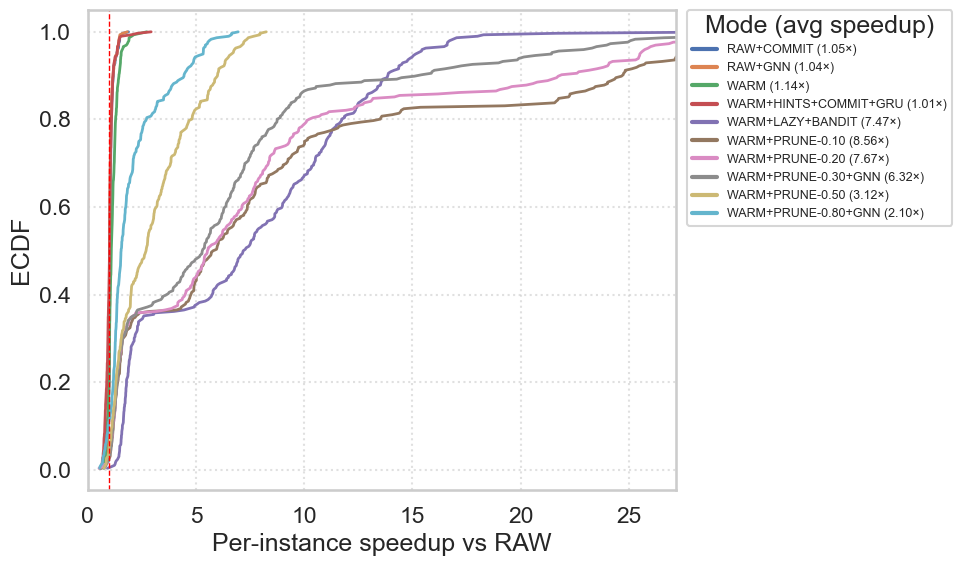

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_requested_modes = [
    "RAW+COMMIT", "RAW+GNN", "WARM", 
    "WARM+HINTS+COMMIT+GRU",
    "WARM+LAZY+BANDIT",
    "WARM+PRUNE-0.10",
    "WARM+PRUNE-0.20",  "WARM+PRUNE-0.30+GNN",
    "WARM+PRUNE-0.50", "WARM+PRUNE-0.80+GNN"
]

if "speedup_inst_df" not in globals():
    raise RuntimeError("speedup_inst_df not available.")

_present_modes = [m for m in _requested_modes if m in speedup_inst_df.columns]
_missing = [m for m in _requested_modes if m not in speedup_inst_df.columns]
if _missing:
    print("Missing modes (skipped):", ", ".join(_missing))
if not _present_modes:
    raise RuntimeError("None of the requested modes are present.")

# Palette via matplotlib
prop_cycle = plt.rcParams["axes.prop_cycle"]
default_colors = prop_cycle.by_key().get("color", [])
# If not enough colors, repeat
if len(default_colors) < len(_present_modes):
    reps = int(np.ceil(len(_present_modes)/max(1,len(default_colors))))
    default_colors = (default_colors * reps)[:len(_present_modes)]
_mode_color_map = dict(zip(_present_modes, default_colors))

# Labels with avg
if "avg_speedup_all" in globals():
    _legend_labels_map = {
        m: f"{m} ({avg_speedup_all[m]:.2f}×)" if m in avg_speedup_all else m
        for m in _present_modes
    }
else:
    _legend_labels_map = {m: m for m in _present_modes}

plt.figure(figsize=(10, 6))
handles = []
labels = []

for m in _present_modes:
    vals = pd.to_numeric(speedup_inst_df[m], errors="coerce").dropna().values
    if vals.size == 0:
        continue
    x = np.sort(vals)
    y = np.arange(1, len(x)+1) / len(x)  # ECDF
    c = _mode_color_map[m]
    plt.plot(x, y, lw=2, label=_legend_labels_map[m], color=c)
    handles.append(Line2D([0], [0], color=c, lw=3))
    labels.append(_legend_labels_map[m])

plt.axvline(1.0, color="red", linestyle="--", linewidth=1)
num_flat = pd.to_numeric(
    speedup_inst_df[_present_modes].stack(), errors="coerce"
).to_numpy()

if np.isfinite(np.nanmax(num_flat)):
    xmax = np.nanpercentile(num_flat, 99)
    if np.isfinite(xmax) and xmax > 0:
        plt.xlim(0, xmax)

if np.isfinite(xmax) and xmax > 0:
    plt.xlim(0, xmax)

plt.xlabel("Per-instance speedup vs RAW")
plt.ylabel("ECDF")
# plt.title("ECDF of per-instance speedups")
plt.grid(axis="both", linestyle=":", alpha=0.6)

plt.legend(
    handles, labels,
    title="Mode (avg speedup)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9,
)

plt.tight_layout()
plt.show()


In [10]:
# Proportion table: for each case_folder & mode, share of OPTIMAL / INFEASIBLE / TIME_LIMIT instances
_status_categories = ["OPTIMAL", "INFEASIBLE", "TIME_LIMIT"]

# Build instance-level status counts (unique instances per status)
_inst_counts = (
    data.groupby(["case_folder", "mode_clean", "status"])["instance_name"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=_status_categories, fill_value=0)
)

_total_inst = _inst_counts.sum(axis=1)
_prop = _inst_counts.div(_total_inst.replace(0, float("nan")), axis=0)

_status_prop_table = _inst_counts.copy()
_status_prop_table.columns = [f"{c}_count" for c in _status_prop_table.columns]
for c in _status_categories:
    _status_prop_table[f"{c}_pct"] = (_prop[c] * 100).round(2)
_status_prop_table["total_instances_tracked"] = _total_inst

# Optional ordering: cases then modes
if "ordered_cases" in globals():
    _idx = _status_prop_table.index
    _ordered = [idx for case in ordered_cases for idx in _idx if idx[0] == case]
    _status_prop_table = _status_prop_table.reindex(_ordered)

# Optional mode ordering within each case
if "modes" in globals():
    _reindexed_rows = []
    _case_iter = (
        ordered_cases
        if "ordered_cases" in globals()
        else _status_prop_table.index.get_level_values(0).unique()
    )
    for case in _case_iter:
        present_modes = [m for m in modes if (case, m) in _status_prop_table.index]
        _reindexed_rows.extend([(case, m) for m in present_modes])
    if _reindexed_rows:
        _status_prop_table = _status_prop_table.reindex(_reindexed_rows)

status_prop_table = _status_prop_table  # keep original detailed table

print("Per (case_folder, mode) status counts and percentages (% of tracked statuses).")
display(status_prop_table.head(30))

# === NEW: Pivot with case as columns, mode as rows, formatted 'OPT/INF/TL' percentages ===
_fmt = (
    status_prop_table[["OPTIMAL_pct", "INFEASIBLE_pct", "TIME_LIMIT_pct"]]
    .round(0)
    .astype(int)
)
_prop_strings = _fmt.apply(
    lambda r: f"{r['OPTIMAL_pct']}/{r['INFEASIBLE_pct']}/{r['TIME_LIMIT_pct']}", axis=1
)

status_prop_matrix = _prop_strings.unstack(level=0)  # columns = case_folder
# Reorder rows (modes) and columns (cases) if ordering lists exist
if "modes" in globals():
    status_prop_matrix = status_prop_matrix.reindex(modes)
if "ordered_cases" in globals():
    status_prop_matrix = status_prop_matrix.reindex(columns=ordered_cases)

status_prop_matrix = status_prop_matrix.fillna("")

print(
    "\nMode (rows) vs Case (columns) percentage triplets (OPTIMAL/INFEASIBLE/TIME_LIMIT)."
)
display(status_prop_matrix)

Per (case_folder, mode) status counts and percentages (% of tracked statuses).


OPTIMAL_count  INFEASIBLE_count  \
case_folder      mode_clean                                               
matpower/case300 RAW+COMMIT                        42                 0   
                 RAW+GNN                           42                 0   
                 WARM                              49                 0   
                 WARM+HINTS                        47                 0   
                 WARM+HINTS+COMMIT                 47                 0   
                 WARM+HINTS+COMMIT+GRU             49                 0   
                 WARM+HINTS+GRU                    49                 0   
                 WARM+LAZY                         59                 0   
                 WARM+LAZY+BANDIT                  59                 0   
                 WARM+LAZY+COMMIT                  59                 0   
                 WARM+LAZY+GRU                     59                 0   
                 WARM+LAZY+K128                    59                 0   
                 WARM+PRUNE-0.10                   59                 0   
                 WARM+PRUNE-0.10+GNN               59                 0   
                 WARM+PRUNE-0.20                   59                 0   
                 WARM+PRUNE-0.20+GNN               59                 0   
                 WARM+PRUNE-0.30                   59                 0   
                 WARM+PRUNE-0.30+GNN               59                 0   
                 WARM+PRUNE-0.50                   59                 0   
                 WARM+PRUNE-0.50+GNN               59                 0   
                 WARM+PRUNE-0.80                   55                 0   
                 WARM+PRUNE-0.80+GNN               54                 0   
matpower/case57  RAW+COMMIT                        46                14   
                 RAW+GNN                           46                14   
                 WARM                              46                14   
                 WARM+HINTS                        46                14   
                 WARM+HINTS+COMMIT                 46                14   
                 WARM+HINTS+COMMIT+GRU             46                14   
                 WARM+HINTS+GRU                    46                14   
                 WARM+LAZY                         46                14   

                                        TIME_LIMIT_count  OPTIMAL_pct  \
case_folder      mode_clean                                             
matpower/case300 RAW+COMMIT                           17        71.19   
                 RAW+GNN                              17        71.19   
                 WARM                                 10        83.05   
                 WARM+HINTS                           12        79.66   
                 WARM+HINTS+COMMIT                    12        79.66   
                 WARM+HINTS+COMMIT+GRU                10        83.05   
                 WARM+HINTS+GRU                       10        83.05   
                 WARM+LAZY                             0       100.00   
                 WARM+LAZY+BANDIT                      0       100.00   
                 WARM+LAZY+COMMIT                      0       100.00   
                 WARM+LAZY+GRU                         0       100.00   
                 WARM+LAZY+K128                        0       100.00   
                 WARM+PRUNE-0.10                       0       100.00   
                 WARM+PRUNE-0.10+GNN                   0       100.00   
                 WARM+PRUNE-0.20                       0       100.00   
                 WARM+PRUNE-0.20+GNN                   0       100.00   
                 WARM+PRUNE-0.30                       0       100.00   
                 WARM+PRUNE-0.30+GNN                   0       100.00   
                 WARM+PRUNE-0.50                       0       100.00   
                 WARM+PRUNE-0.50+GNN                   0       100.00   
                 WARM+PRUNE-0.80 


Mode (rows) vs Case (columns) percentage triplets (OPTIMAL/INFEASIBLE/TIME_LIMIT).


case_folder,matpower/case300,matpower/case57,matpower/case89pegase,matpower/case30,matpower/case14,matpower/case118
mode_clean,,,,,,
RAW+COMMIT,71/0/29,77/23/0,100/0/0,100/0/0,100/0/0,98/0/2
RAW+GNN,71/0/29,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0
WARM,83/0/17,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0
WARM+HINTS,80/0/20,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0
WARM+HINTS+COMMIT,80/0/20,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0
WARM+HINTS+COMMIT+GRU,83/0/17,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0
WARM+HINTS+GRU,83/0/17,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0
WARM+LAZY,100/0/0,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0
WARM+LAZY+BANDIT,100/0/0,77/23/0,100/0/0,100/0/0,100/0/0,100/0/0


In [11]:
# Per-case / per-mode average speedup vs RAW (instances equally weighted per case)
# Reuse existing computations; compute minimally if absent.

if "speedup_inst_df" not in globals():
    raise RuntimeError("speedup_inst_df not available (needs RAW baseline).")

# Ensure per-case average speedup matrix exists (rows=case_folder, cols=mode)
if "avg_speedup" not in globals():
    avg_speedup = speedup_inst_df.groupby(level="case_folder").mean()

# Case ordering (reuse existing ordering if present)
_case_order = ordered_cases if "ordered_cases" in globals() else list(avg_speedup.index)

# Mode ordering (respect existing 'modes' list, filtered to those present)
if "modes" in globals():
    _mode_order = [m for m in modes if m in avg_speedup.columns]
else:
    _mode_order = list(avg_speedup.columns)

# Build matrix with modes as rows, cases as columns
speedup_case_mode_matrix = avg_speedup.reindex(index=_case_order).T.reindex(_mode_order)

# Create formatted version with 'x' suffix and star marking the best per case
_formatted = speedup_case_mode_matrix.copy()
_col_max = speedup_case_mode_matrix.max(axis=0)


def _fmt(val, best):
    if pd.isna(val):
        return ""
    star = "*" if abs(val - best) < 1e-12 else ""
    return f"{val:.2f}x{star}"


for c in speedup_case_mode_matrix.columns:
    best_val = _col_max[c]
    _formatted[c] = speedup_case_mode_matrix[c].map(lambda v, b=best_val: _fmt(v, b))

speedup_case_mode_formatted = _formatted  # exposed for later reuse

print(
    "Per-mode average speedup vs RAW (rows=modes, cols=cases). '*' marks best per case."
)
display(speedup_case_mode_formatted)

# (Optional) styled numeric view with gradient (uncomment if desired)
# speedup_case_mode_matrix.style.background_gradient(cmap="RdYlGn", axis=None)

Per-mode average speedup vs RAW (rows=modes, cols=cases). '*' marks best per case.


case_folder,matpower/case300,matpower/case57,matpower/case89pegase,matpower/case30,matpower/case14,matpower/case118
RAW+COMMIT,1.03x,1.05x,1.09x,1.03x,1.07x,1.02x
RAW+GNN,1.02x,1.03x,1.09x,1.02x,1.05x,1.01x
WARM,1.18x,1.19x,1.43x,0.98x,1.06x,1.02x
WARM+HINTS,1.17x,1.19x,1.41x,0.96x,1.07x,1.01x
WARM+HINTS+COMMIT,1.18x,1.21x,1.43x,0.94x,1.07x,1.01x
WARM+HINTS+COMMIT+GRU,1.17x,1.02x,1.08x,0.92x,0.85x,1.02x
WARM+HINTS+GRU,1.16x,0.99x,1.07x,0.93x,0.87x,1.01x
WARM+LAZY,13.14x*,6.25x,12.77x,1.84x*,1.65x,8.97x
WARM+LAZY+BANDIT,13.11x,6.30x*,12.82x,1.84x,1.77x*,9.00x*
WARM+LAZY+COMMIT,13.08x,6.27x,12.80x,1.84x,1.76x,8.86x


In [13]:
# Build per-case family runtime summary: mean [min - max] over OPTIMAL runs only.

# Reuse existing df_ok (OPTIMAL rows) or create if absent
if "df_ok" not in globals():
    df_ok = data.loc[
        data["status"] == "OPTIMAL",
        ["case_folder", "instance_name", "mode_clean", "runtime_sec"],
    ]

# Fallback definition if mode_family not yet executed
# Focus analysis on specific modes of interest; group all others as OTHER
_target_modes = {"WARM+LAZY+BANDIT", "WARM+PRUNE-0.10", "RAW"}

def mode_family(m: str) -> str:
    return m if m in _target_modes else "OTHER"

# Column ordering (RAW first, then the two target modes, then OTHER)
_family_order = ["RAW", "WARM+LAZY+BANDIT", "WARM+PRUNE-0.10", "OTHER"]

_family_df = df_ok.copy()
_family_df["family"] = _family_df["mode_clean"].map(mode_family)

# Aggregate per (case, family)
family_runtime_stats = (
    _family_df.groupby(["case_folder", "family"])["runtime_sec"]
    .agg(mean="mean", min="min", max="max", n="count")
    .reset_index()
)

# Optional: ensure family ordering
family_runtime_stats["family"] = pd.Categorical(
    family_runtime_stats["family"],
    categories=[
        f for f in _family_order if f in family_runtime_stats["family"].unique()
    ],
    ordered=True,
)
family_runtime_stats = family_runtime_stats.sort_values(["case_folder", "family"])

# Create formatted string: avg [min - max]
family_runtime_stats["summary"] = (
    family_runtime_stats["mean"].map(lambda v: f"{v:.2f}") + " [" +
    family_runtime_stats["min"].map(lambda v: f"{v:.2f}") + " - " +
    family_runtime_stats["max"].map(lambda v: f"{v:.2f}") + "]"
)

# Pivot to wide table (rows = case_folder, columns = family)
family_runtime_summary = family_runtime_stats.pivot(
    index="case_folder", columns="family", values="summary"
).reindex(index=sorted(family_runtime_stats["case_folder"].unique()))

print("Average runtime (sec) with range per family (OPTIMAL runs only):")
display(family_runtime_summary)

# (Optional) numeric version if needed later
family_runtime_summary_numeric = family_runtime_stats.pivot(
    index="case_folder", columns="family", values="mean"
)

Average runtime (sec) with range per family (OPTIMAL runs only):


family,RAW,WARM+LAZY+BANDIT,WARM+PRUNE-0.10,OTHER
case_folder,,,,
matpower/case118,43.40 [25.79 - 66.25],4.84 [3.74 - 7.67],5.69 [3.27 - 20.86],23.96 [3.12 - 96.22]
matpower/case14,0.08 [0.06 - 0.13],0.05 [0.03 - 0.07],0.06 [0.04 - 0.11],0.07 [0.03 - 0.17]
matpower/case30,0.15 [0.12 - 0.22],0.08 [0.06 - 0.17],0.11 [0.06 - 0.19],0.12 [0.06 - 0.26]
matpower/case300,189.90 [135.81 - 393.03],15.00 [11.32 - 20.48],22.12 [13.17 - 33.90],92.45 [11.26 - 397.51]
matpower/case57,0.65 [0.54 - 0.77],0.11 [0.08 - 0.20],0.12 [0.08 - 0.22],0.29 [0.07 - 0.91]
matpower/case89pegase,12.31 [9.19 - 16.84],0.97 [0.75 - 1.37],0.49 [0.33 - 0.84],4.90 [0.35 - 16.24]


In [ ]:
# High-level descriptive statistics about the dataset

# Safe retrieval with fallback recomputation
_total_rows = total_rows if "total_rows" in globals() else len(data)
_unique_cases = (
    unique_case_folders
    if "unique_case_folders" in globals()
    else data["case_folder"].nunique()
)
_unique_instances = (
    total_unique_instances
    if "total_unique_instances" in globals()
    else data["instance_name"].nunique()
)
_unique_modes = (
    unique_modes if "unique_modes" in globals() else data["mode_clean"].nunique()
)

# Status counts
if "statuses_counts" in globals():
    status_counts = statuses_counts.copy()
else:
    status_counts = data["status"].value_counts()

status_shares = (status_counts / _total_rows * 100).round(2)

# Instances with at least one OPTIMAL solve
opt_instances = data.loc[data["status"] == "OPTIMAL", "instance_name"].nunique()

# Instances fully solved optimally across all their (case_folder, mode) rows (no TIME_LIMIT / INFEASIBLE)
grp = data.groupby(["case_folder", "instance_name"])
fully_opt_instances = grp["status"].apply(lambda s: (s == "OPTIMAL").all()).sum()

# Instances with at least one failure (INFEASIBLE or TIME_LIMIT)
instances_with_any_failure = (
    grp["status"]
    .apply(lambda s: ((s == "INFEASIBLE") | (s == "TIME_LIMIT")).any())
    .sum()
)

# Per-mode coverage (how many unique instances each mode appears in)
mode_instance_coverage = (
    data.groupby("mode_clean")["instance_name"]
    .nunique()
    .rename("instances_covered")
    .sort_values(ascending=False)
)

# Fully optimal (case,instance,mode) triplets if already computed
opt_triplets_count = (
    opt_triplets if "opt_triplets" in globals() else (data["status"] == "OPTIMAL").sum()
)

# Total runtime (if aggregated earlier)
_total_runtime_sec = (
    total_runtime_sec if "total_runtime_sec" in globals() else data["runtime_sec"].sum()
)
_total_runtime_hours = (
    total_runtime_hours
    if "total_runtime_hours" in globals()
    else (_total_runtime_sec / 3600)
)

# Median / percentiles over all runs
median_rt = (
    median_runtime if "median_runtime" in globals() else data["runtime_sec"].median()
)
p90_rt = (
    p90_runtime if "p90_runtime" in globals() else data["runtime_sec"].quantile(0.90)
)
p95_rt = (
    p95_runtime if "p95_runtime" in globals() else data["runtime_sec"].quantile(0.95)
)
min_rt = min_runtime if "min_runtime" in globals() else data["runtime_sec"].min()
max_rt = max_runtime if "max_runtime" in globals() else data["runtime_sec"].max()

summary = {
    "Total rows (runs)": _total_rows,
    "Unique case folders": _unique_cases,
    "Unique instances": _unique_instances,
    "Unique modes": _unique_modes,
    "Total runtime (sec)": round(_total_runtime_sec, 2),
    "Total runtime (hours)": round(_total_runtime_hours, 2),
    "Median runtime (sec)": round(median_rt, 4),
    "P90 runtime (sec)": round(p90_rt, 4),
    "P95 runtime (sec)": round(p95_rt, 4),
    "Min runtime (sec)": round(min_rt, 6),
    "Max runtime (sec)": round(max_rt, 6),
    "OPTIMAL rows": int(status_counts.get("OPTIMAL", 0)),
    "INFEASIBLE rows": int(status_counts.get("INFEASIBLE", 0)),
    "TIME_LIMIT rows": int(status_counts.get("TIME_LIMIT", 0)),
    "OPTIMAL row share %": status_shares.get("OPTIMAL", 0.0),
    "Solved instances (>=1 OPTIMAL)": opt_instances,
    "Solved instance share %": round(opt_instances / _unique_instances * 100, 2)
    if _unique_instances
    else None,
    "Fully optimal instances (all runs OPTIMAL)": int(fully_opt_instances),
    "Instances with any failure": int(instances_with_any_failure),
    "OPTIMAL triplets (row count)": int(opt_triplets_count),
}

print("=== Dataset Summary ===")
for k, v in summary.items():
    print(f"{k}: {v}")

print("\n=== Status Distribution (rows) ===")
for st, cnt in status_counts.items():
    print(f"{st}: {cnt} ({status_shares[st]}%)")

print("\n=== Top modes by instance coverage ===")
display(mode_instance_coverage.to_frame().head(10))

if "runtime_stats_mode" in globals() and runtime_stats_mode is not None:
    print("=== Runtime stats (selected columns) ===")
    cols = [
        "n_rows",
        "row_opt_rate_%",
        "total_runtime_sec",
        "mean",
        "median",
        "p90",
        "max",
    ]
    display(
        runtime_stats_mode[cols]
        .sort_values("total_runtime_sec", ascending=False)
        .head(10)
    )

=== Dataset Summary ===
Total rows (runs): 7682
Unique case folders: 6
Unique instances: 327
Unique modes: 23
Total runtime (sec): 264127.91
Total runtime (hours): 73.37
Median runtime (sec): 0.6055
P90 runtime (sec): 62.719
P95 runtime (sec): 172.9443
Min runtime (sec): 0.014
Max runtime (sec): 9482.394
OPTIMAL rows: 7215
INFEASIBLE rows: 322
TIME_LIMIT rows: 145
OPTIMAL row share %: 93.92
Solved instances (>=1 OPTIMAL): 313
Solved instance share %: 95.72
Fully optimal instances (all runs OPTIMAL): 294
Instances with any failure: 33
OPTIMAL triplets (row count): 7215

=== Status Distribution (rows) ===
OPTIMAL: 7215 (93.92%)
INFEASIBLE: 322 (4.19%)
TIME_LIMIT: 145 (1.89%)

=== Top modes by instance coverage ===


,instances_covered
mode_clean,
RAW,327
WARM+LAZY+K128,327
WARM+PRUNE-0.80,327
WARM+PRUNE-0.50+GNN,327
WARM+PRUNE-0.50,327
WARM+PRUNE-0.30+GNN,327
WARM+PRUNE-0.30,327
WARM+PRUNE-0.20+GNN,327
WARM+PRUNE-0.20,327


In [ ]:
import numpy as np

# Extended high-level descriptive statistics (text only, no tables)

# --- ORIGINAL SUMMARY (adjusted: no DataFrame displays) ---

# Safe retrieval with fallback recomputation
_total_rows = total_rows if "total_rows" in globals() else len(data)
_unique_cases = (
    unique_case_folders
    if "unique_case_folders" in globals()
    else data["case_folder"].nunique()
)
_unique_instances = (
    total_unique_instances
    if "total_unique_instances" in globals()
    else data["instance_name"].nunique()
)
_unique_modes = (
    unique_modes if "unique_modes" in globals() else data["mode_clean"].nunique()
)

# Status counts (prefer existing)
if "statuses_counts" in globals():
    status_counts = statuses_counts.copy()
else:
    status_counts = data["status"].value_counts()

status_shares = (status_counts / _total_rows * 100).round(2)

# Instances with at least one OPTIMAL solve
opt_instances = (
    opt_instances
    if "opt_instances" in globals()
    else (data.loc[data["status"] == "OPTIMAL", "instance_name"].nunique())
)

# Fully optimal instances (all rows OPTIMAL)
if "fully_opt_instances" not in globals():
    grp = data.groupby(["case_folder", "instance_name"])
    fully_opt_instances = grp["status"].apply(lambda s: (s == "OPTIMAL").all()).sum()

# Instances with any failure
if "instances_with_any_failure" not in globals():
    grp = data.groupby(["case_folder", "instance_name"])
    instances_with_any_failure = (
        grp["status"]
        .apply(lambda s: ((s == "INFEASIBLE") | (s == "TIME_LIMIT")).any())
        .sum()
    )

# Per-mode coverage
if "mode_instance_coverage" not in globals():
    mode_instance_coverage = (
        data.groupby("mode_clean")["instance_name"]
        .nunique()
        .rename("instances_covered")
        .sort_values(ascending=False)
    )

# Optimal triplets
opt_triplets_count = (
    opt_triplets if "opt_triplets" in globals() else (data["status"] == "OPTIMAL").sum()
)

# Total runtime aggregates
_total_runtime_sec = (
    total_runtime_sec if "total_runtime_sec" in globals() else data["runtime_sec"].sum()
)
_total_runtime_hours = (
    total_runtime_hours
    if "total_runtime_hours" in globals()
    else (_total_runtime_sec / 3600)
)

# Runtime percentiles
median_rt = (
    median_runtime if "median_runtime" in globals() else data["runtime_sec"].median()
)
p90_rt = (
    p90_runtime if "p90_runtime" in globals() else data["runtime_sec"].quantile(0.90)
)
p95_rt = (
    p95_runtime if "p95_runtime" in globals() else data["runtime_sec"].quantile(0.95)
)
min_rt = min_runtime if "min_runtime" in globals() else data["runtime_sec"].min()
max_rt = max_runtime if "max_runtime" in globals() else data["runtime_sec"].max()

summary = {
    "Total rows (runs)": _total_rows,
    "Unique case folders": _unique_cases,
    "Unique instances": _unique_instances,
    "Unique modes": _unique_modes,
    "Total runtime (sec)": round(_total_runtime_sec, 2),
    "Total runtime (hours)": round(_total_runtime_hours, 2),
    "Median runtime (sec)": round(median_rt, 4),
    "P90 runtime (sec)": round(p90_rt, 4),
    "P95 runtime (sec)": round(p95_rt, 4),
    "Min runtime (sec)": round(min_rt, 6),
    "Max runtime (sec)": round(max_rt, 6),
    "OPTIMAL rows": int(status_counts.get("OPTIMAL", 0)),
    "INFEASIBLE rows": int(status_counts.get("INFEASIBLE", 0)),
    "TIME_LIMIT rows": int(status_counts.get("TIME_LIMIT", 0)),
    "OPTIMAL row share %": status_shares.get("OPTIMAL", 0.0),
    "Solved instances (>=1 OPTIMAL)": int(opt_instances),
    "Solved instance share %": round(opt_instances / _unique_instances * 100, 2)
    if _unique_instances
    else None,
    "Fully optimal instances (all runs OPTIMAL)": int(fully_opt_instances),
    "Instances with any failure": int(instances_with_any_failure),
    "OPTIMAL triplets (row count)": int(opt_triplets_count),
}

lines = []
lines.append("=== DATASET SUMMARY ===")
for k, v in summary.items():
    lines.append(f"{k}: {v}")

lines.append("")
lines.append("=== STATUS DISTRIBUTION (ROWS) ===")
for st, cnt in status_counts.items():
    lines.append(f"{st}: {cnt} ({status_shares[st]}%)")

# --- ADDITIONAL MODE / PERFORMANCE STATISTICS ---

# Average speedup vs RAW (needs avg_speedup_all)
if "avg_speedup_all" not in globals():
    # Recompute minimally if needed
    if "speedup_inst_df" not in globals():
        if "pvt" not in globals() and "data" in globals():
            df_ok_local = data.loc[
                data["status"] == "OPTIMAL",
                ["case_folder", "instance_name", "mode_clean", "runtime_sec"],
            ]
            pvt_local = df_ok_local.pivot_table(
                index=["case_folder", "instance_name"],
                columns="mode_clean",
                values="runtime_sec",
                aggfunc="mean",
            )
        else:
            pvt_local = pvt
        if "RAW" in pvt_local.columns:
            modes_local = [m for m in pvt_local.columns if m != "RAW"]
            speedup_inst_df = pd.DataFrame(
                {m: pvt_local["RAW"] / pvt_local[m] for m in modes_local},
                index=pvt_local.index,
            )
    if "speedup_inst_df" in globals():
        avg_speedup_all = speedup_inst_df.groupby(lambda idx: True).mean().iloc[0]

if "avg_speedup_all" in globals():
    top_speedups = avg_speedup_all.sort_values(ascending=False)
    lines.append("")
    lines.append("=== TOP MODES BY AVERAGE SPEEDUP VS RAW ===")
    for m, v in top_speedups.head(8).items():
        opt_share_val = None
        if "opt_share_by_mode" in globals():
            opt_share_val = opt_share_by_mode.get(m, None)
        if opt_share_val is not None:
            lines.append(f"{m}: avg_speedup={v:.4f}, opt_share={opt_share_val:.4f}")
        else:
            lines.append(f"{m}: avg_speedup={v:.4f}")

    best_mode = top_speedups.index[0]
    lines.append(
        f"Best average speedup mode: {best_mode} ({top_speedups.iloc[0]:.4f}x)"
    )

# Optimality share extremes
if "opt_share_by_mode" in globals():
    opt_sorted = opt_share_by_mode.sort_values(ascending=False)
    lines.append("")
    lines.append("=== HIGHEST OPTIMALITY SHARE MODES ===")
    for m, v in opt_sorted.head(5).items():
        lines.append(f"{m}: opt_share={v:.4f}")
    opt_low = opt_sorted.tail(5)
    lines.append("=== LOWEST OPTIMALITY SHARE MODES ===")
    for m, v in opt_low.items():
        lines.append(f"{m}: opt_share={v:.4f}")

# Win rates (per instance best speedup)
if "win_share_mode" in globals():
    lines.append("")
    lines.append("=== TOP MODES BY WIN RATE (BEST PER-INSTANCE SPEEDUP) ===")
    total_instances_for_win = (
        int(win_share_mode.sum() * _unique_instances) if _unique_instances else None
    )
    for m, v in win_share_mode.head(8).items():
        lines.append(f"{m}: win_share={v * 100:.2f}%")
    lines.append(f"Unique winning modes counted: {len(win_share_mode)}")

if "win_share_family" in globals():
    lines.append("")
    lines.append("=== MODE FAMILY WIN SHARE ===")
    for fam, v in win_share_family.items():
        lines.append(f"{fam}: win_share={v * 100:.2f}%")

# Runtime efficiency (median + total runtime)
if "runtime_stats_mode" in globals() and runtime_stats_mode is not None:
    # Fastest median runtime among widely covered modes (coverage >= 90% of instances)
    cov_threshold = 0.9 * _unique_instances
    rs = runtime_stats_mode.copy()
    widely = rs[rs["inst_covered"] >= cov_threshold]
    if not widely.empty:
        fastest_median = widely.sort_values("median").head(5)
        lines.append("")
        lines.append("=== FASTEST MEDIAN RUNTIME (WIDELY COVERED MODES) ===")
        for idx, r in fastest_median.iterrows():
            lines.append(
                f"{idx}: median={r['median']:.4f}s p90={r['p90']:.2f}s total_runtime_sec={r['total_runtime_sec']:.1f}"
            )
    # Largest total runtime consumers
    heavy = rs.sort_values("total_runtime_sec", ascending=False).head(5)
    lines.append("")
    lines.append("=== HIGHEST TOTAL RUNTIME MODES ===")
    for idx, r in heavy.iterrows():
        lines.append(
            f"{idx}: total_runtime_sec={r['total_runtime_sec']:.1f} median={r['median']:.4f}s"
        )

# Coverage distribution (modes per instance)
if "modes_per_instance_counts_df" in globals():
    lines.append("")
    lines.append("=== MODES PER INSTANCE DISTRIBUTION ===")
    for n_modes, row in modes_per_instance_counts_df.iterrows():
        lines.append(
            f"{int(n_modes)} modes: n_instances={int(row['n_instances'])} share={row['share_%']:.2f}%"
        )

# Completeness of speedup matrix
if "speedup_inst_df" in globals():
    total_cells = speedup_inst_df.shape[0] * speedup_inst_df.shape[1]
    non_null = speedup_inst_df.count().sum()
    completeness = non_null / total_cells * 100 if total_cells else 0
    lines.append("")
    lines.append("=== SPEEDUP MATRIX COMPLETENESS ===")
    lines.append(f"Non-null entries: {non_null} / {total_cells} ({completeness:.2f}%)")

# Correlation between average speedup and optimality share
if "avg_speedup_all" in globals() and "opt_share_by_mode" in globals():
    inter = avg_speedup_all.index.intersection(opt_share_by_mode.index)
    if len(inter) >= 3:
        sp = avg_speedup_all.reindex(inter)
        op = opt_share_by_mode.reindex(inter)
        try:
            if "np" not in globals():
                corr = np.corrcoef(sp.values, op.values)[0, 1]
                lines.append("")
                lines.append("=== CORRELATION ===")
                lines.append(f"Pearson corr(avg_speedup, opt_share)={corr:.4f}")
        except Exception:
            pass

# Family-level best representative
if "sumdf" in globals():
    fam_best = (
        sumdf.sort_values("avg_speedup", ascending=False)
        .groupby("family")
        .first()[["avg_speedup", "opt_share"]]
    )
    lines.append("")
    lines.append("=== BEST MODE PER FAMILY (BY AVG SPEEDUP) ===")
    for fam, row in fam_best.iterrows():
        lines.append(
            f"{fam}: mode={row.name if isinstance(row.name, str) else ''} avg_speedup={row['avg_speedup']:.4f} opt_share={row['opt_share']:.4f}"
        )

# Identify diminishing returns (modes with avg_speedup < 1.05 and opt_share >= median opt_share)
if "avg_speedup_all" in globals() and "opt_share_by_mode" in globals():
    median_opt = opt_share_by_mode.median()
    low_gain = [
        m
        for m in avg_speedup_all.index
        if avg_speedup_all[m] < 1.05 and opt_share_by_mode.get(m, 0) >= median_opt
    ]
    if low_gain:
        lines.append("")
        lines.append(
            "=== LOW SPEEDUP BUT HIGH OPTIMALITY (POTENTIAL PRUNE CANDIDATES) ==="
        )
        for m in low_gain:
            lines.append(
                f"{m}: avg_speedup={avg_speedup_all[m]:.4f} opt_share={opt_share_by_mode[m]:.4f}"
            )

# Print all lines
print("\n".join(lines))

=== DATASET SUMMARY ===
Total rows (runs): 7682
Unique case folders: 6
Unique instances: 327
Unique modes: 23
Total runtime (sec): 264127.91
Total runtime (hours): 73.37
Median runtime (sec): 0.6055
P90 runtime (sec): 62.719
P95 runtime (sec): 172.9443
Min runtime (sec): 0.014
Max runtime (sec): 9482.394
OPTIMAL rows: 7215
INFEASIBLE rows: 322
TIME_LIMIT rows: 145
OPTIMAL row share %: 93.92
Solved instances (>=1 OPTIMAL): 313
Solved instance share %: 95.72
Fully optimal instances (all runs OPTIMAL): 294
Instances with any failure: 33
OPTIMAL triplets (row count): 7215

=== STATUS DISTRIBUTION (ROWS) ===
OPTIMAL: 7215 (93.92%)
INFEASIBLE: 322 (4.19%)
TIME_LIMIT: 145 (1.89%)

=== TOP MODES BY AVERAGE SPEEDUP VS RAW ===
WARM+PRUNE-0.10: avg_speedup=8.5576, opt_share=0.9611
WARM+PRUNE-0.10+GNN: avg_speedup=8.5091, opt_share=0.9611
WARM+PRUNE-0.20: avg_speedup=7.6689, opt_share=0.9611
WARM+PRUNE-0.20+GNN: avg_speedup=7.6428, opt_share=0.9611
WARM+LAZY+BANDIT: avg_speedup=7.4743, opt_share=0